# Walk-Forward Backtest: 1975–Present

Testing allocation strategies using only data available at each point in time.
Compares the Big Cycle adaptive strategy against static benchmarks.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from src.data_fetcher import load_series
from src.backtester import (
    build_asset_returns, run_backtest, compute_metrics, format_metrics,
    StaticStrategy, AllWeatherStrategy, BigCycleStrategy,
)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

RECESSIONS = [
    ('1973-11-01', '1975-03-01'),
    ('1980-01-01', '1980-07-01'),
    ('1981-07-01', '1982-11-01'),
    ('1990-07-01', '1991-03-01'),
    ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01'),
]

def add_recessions(ax):
    for start, end in RECESSIONS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color='gray')

print('Loaded.')

Loaded.


## 1. Load Data & Build Asset Returns

In [2]:
# Load all needed data
raw = {
    # Asset prices
    '^GSPC': load_series('yahoo', '^GSPC'),
    '^TNX': load_series('yahoo', '^TNX'),
    'GC=F': load_series('yahoo', 'GC=F'),
    'CL=F': load_series('yahoo', 'CL=F'),
    # Indicators
    'FEDFUNDS': load_series('fred', 'FEDFUNDS'),
    'CPIAUCSL': load_series('fred', 'CPIAUCSL'),
    'GS2': load_series('fred', 'GS2'),
}

# Yield curve — use precomputed T10Y2Y if available, else compute from TNX - GS2
try:
    raw['T10Y2Y'] = load_series('fred', 'T10Y2Y')
except FileNotFoundError:
    tnx_daily = raw['^TNX']['Close']
    gs2_monthly = raw['GS2'].squeeze()
    gs2_daily = gs2_monthly.resample('D').ffill()
    raw['T10Y2Y'] = (tnx_daily - gs2_daily).dropna().to_frame('spread')

# Build 2Y yield series for short bond proxy
gs2_daily = raw['GS2'].squeeze().resample('D').ffill()
raw['GS2_yield'] = gs2_daily

# Build asset returns
asset_returns = build_asset_returns(raw, start='1975-01-01')

print('Asset return coverage:')
for col in asset_returns.columns:
    valid = asset_returns[col][asset_returns[col] != 0]
    if len(valid) > 0:
        print(f'  {col:15s}: {valid.index.min().date()} → {valid.index.max().date()} ({len(valid)} days)')
    else:
        print(f'  {col:15s}: no data')

Asset return coverage:
  equities       : 1975-01-03 → 2026-04-10 (12903 days)
  long_bonds     : 1975-01-03 → 2026-04-10 (12842 days)
  short_bonds    : 1976-06-02 → 2026-03-01 (18170 days)
  gold           : 2000-08-31 → 2026-04-10 (6380 days)
  commodities    : 2000-08-24 → 2026-04-10 (6406 days)
  cash           : 1975-01-01 → 2026-03-01 (18688 days)


## 2. Define Strategies

- **60/40**: Classic stock/bond split
- **All Weather**: Bridgewater-inspired risk parity (simplified)
- **Big Cycle v1**: Regime-adaptive — shifts allocation based on yield curve, inflation, and real rates

In [3]:
strategies = {
    '60/40': StaticStrategy(
        weights={'equities': 0.60, 'long_bonds': 0.40},
        name='60/40'
    ),
    'All Weather': AllWeatherStrategy(),
    'Big Cycle v1': BigCycleStrategy(),
}

print('Strategies defined:', list(strategies.keys()))

Strategies defined: ['60/40', 'All Weather', 'Big Cycle v1']


## 3. Run Backtests

In [4]:
results = {}
for name, strategy in strategies.items():
    print(f'Running {name}...')
    results[name] = run_backtest(
        strategy=strategy,
        asset_returns=asset_returns,
        indicator_data=raw,
        start='1976-07-01',  # after GS2 starts (1976-06)
        rebalance_freq='QE',
    )
    metrics = compute_metrics(results[name])
    print(format_metrics(metrics))
    print()

Running 60/40...


Period:        1976-07-01 → 2026-04-10 (49.8 years)
Total Return:  4792.1%
CAGR:          8.13%
Volatility:    9.04%
Sharpe Ratio:  0.90
Max Drawdown:  -33.1% (2009-03-09)
Recovery:      674 days
Calmar Ratio:  0.25

Running All Weather...


Period:        1976-07-01 → 2026-04-10 (49.8 years)
Total Return:  3713.2%
CAGR:          7.59%
Volatility:    6.71%
Sharpe Ratio:  1.13
Max Drawdown:  -24.9% (2020-04-20)
Recovery:      28 days
Calmar Ratio:  0.30

Running Big Cycle v1...


Period:        1976-07-01 → 2026-04-10 (49.8 years)
Total Return:  3804.4%
CAGR:          7.64%
Volatility:    7.80%
Sharpe Ratio:  0.98
Max Drawdown:  -34.2% (2020-04-20)
Recovery:      39 days
Calmar Ratio:  0.22



## 4. Cumulative Performance

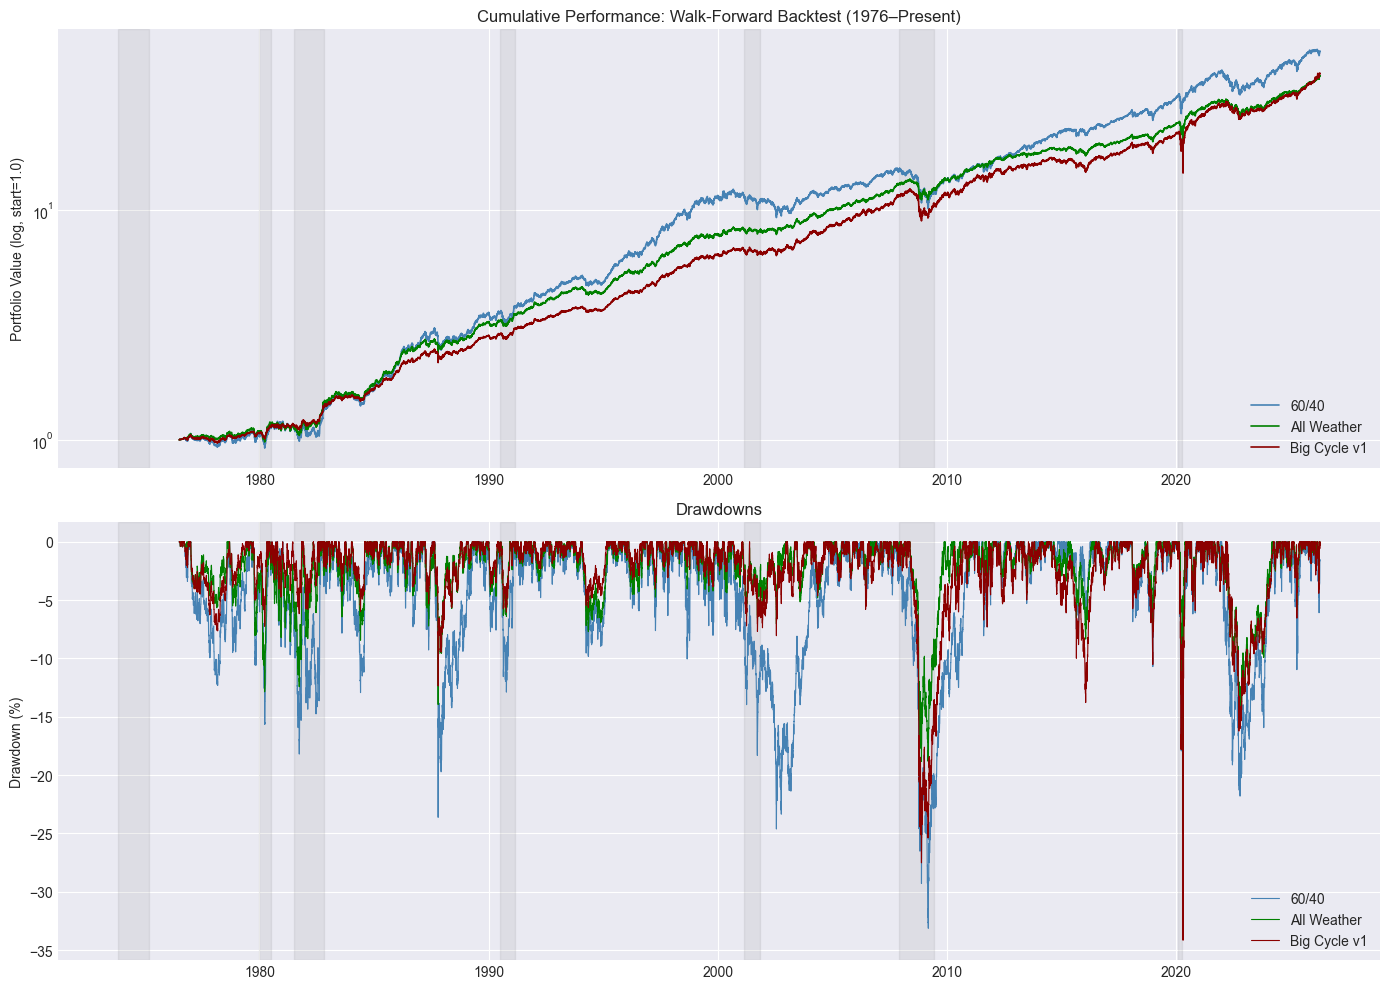

In [5]:
colors = {'60/40': 'steelblue', 'All Weather': 'green', 'Big Cycle v1': 'darkred'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Cumulative value (log scale)
for name, result in results.items():
    ax1.semilogy(result.portfolio_value.index, result.portfolio_value,
                 label=name, color=colors[name], linewidth=1.2)
add_recessions(ax1)
ax1.set_ylabel('Portfolio Value (log, start=1.0)')
ax1.set_title('Cumulative Performance: Walk-Forward Backtest (1976–Present)')
ax1.legend()

# Drawdowns
for name, result in results.items():
    peak = result.portfolio_value.cummax()
    dd = (result.portfolio_value - peak) / peak
    ax2.plot(dd.index, dd * 100, label=name, color=colors[name], linewidth=0.8)
add_recessions(ax2)
ax2.set_ylabel('Drawdown (%)')
ax2.set_title('Drawdowns')
ax2.legend()

plt.tight_layout()
plt.show()

## 5. Regime History & Weight Shifts

How the Big Cycle strategy adapted its allocation over time.

/var/folders/ht/8j5223dn0kjcsdchf0d9k4t00000gn/T/ipykernel_31063/2535707909.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


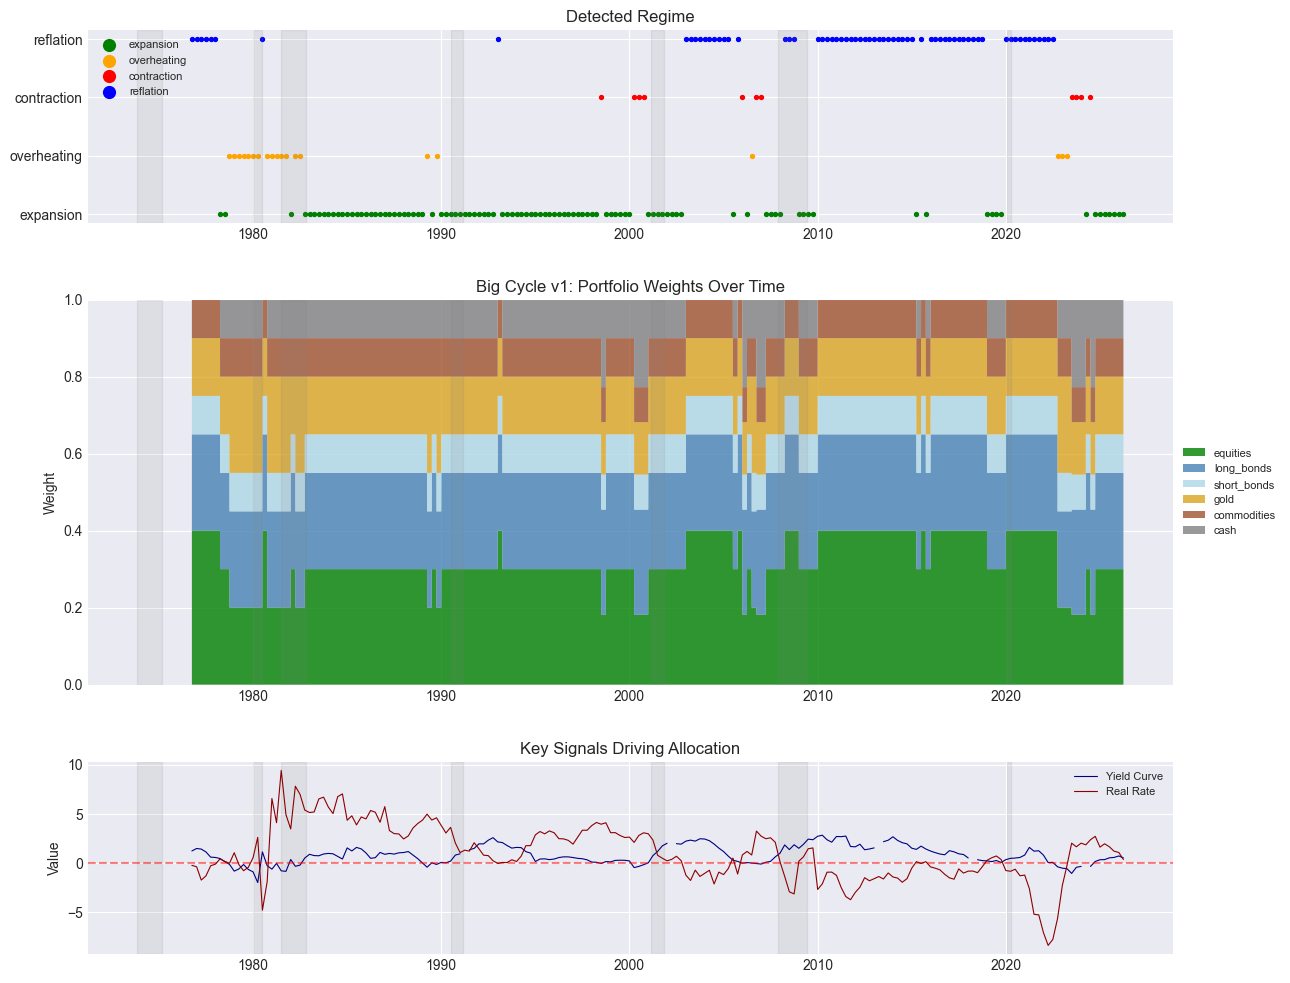

In [6]:
bc = results['Big Cycle v1']

fig = plt.figure(figsize=(14, 12))
gs = GridSpec(3, 1, figure=fig, height_ratios=[1, 2, 1], hspace=0.3)

# Regime timeline
ax1 = fig.add_subplot(gs[0])
regime_colors = {'expansion': 'green', 'overheating': 'orange', 'contraction': 'red', 'reflation': 'blue'}
for regime, color in regime_colors.items():
    mask = bc.regime_history == regime
    if mask.any():
        ax1.scatter(bc.regime_history.index[mask], [regime] * mask.sum(),
                    c=color, s=8, label=regime)
add_recessions(ax1)
ax1.set_title('Detected Regime')
ax1.legend(markerscale=3, fontsize=8)

# Weight allocation over time (stacked area)
ax2 = fig.add_subplot(gs[1])
w = bc.weights_history
# Forward-fill to daily for visualization
w_daily = w.resample('D').ffill()
asset_colors = {
    'equities': 'green', 'long_bonds': 'steelblue', 'short_bonds': 'lightblue',
    'gold': 'goldenrod', 'commodities': 'sienna', 'cash': 'gray'
}
plot_cols = [c for c in w.columns if c in asset_colors]
ax2.stackplot(w_daily.index, *[w_daily[c] for c in plot_cols],
              labels=plot_cols, colors=[asset_colors[c] for c in plot_cols], alpha=0.8)
add_recessions(ax2)
ax2.set_ylabel('Weight')
ax2.set_title('Big Cycle v1: Portfolio Weights Over Time')
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax2.set_ylim(0, 1)

# Key signals
ax3 = fig.add_subplot(gs[2])
signal_data = []
for snap in bc.snapshots:
    row = {'date': snap.date}
    row.update(snap.signals)
    signal_data.append(row)
signals_df = pd.DataFrame(signal_data).set_index('date')
if 'yield_curve' in signals_df.columns:
    ax3.plot(signals_df.index, signals_df['yield_curve'], label='Yield Curve', color='navy', linewidth=0.8)
    ax3.axhline(0, color='red', linestyle='--', alpha=0.5)
if 'real_rate' in signals_df.columns:
    ax3.plot(signals_df.index, signals_df['real_rate'], label='Real Rate', color='darkred', linewidth=0.8)
add_recessions(ax3)
ax3.set_ylabel('Value')
ax3.set_title('Key Signals Driving Allocation')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Performance by Decade

How each strategy performed across different macro regimes.

In [7]:
decades = [
    ('1976-07-01', '1979-12-31', 'Late 70s (stagflation)'),
    ('1980-01-01', '1989-12-31', '1980s (Volcker/Reagan)'),
    ('1990-01-01', '1999-12-31', '1990s (boom)'),
    ('2000-01-01', '2009-12-31', '2000s (bubbles & bust)'),
    ('2010-01-01', '2019-12-31', '2010s (QE/low rates)'),
    ('2020-01-01', None, '2020s (COVID & after)'),
]

rows = []
for start, end, label in decades:
    row = {'Period': label}
    for name, result in results.items():
        vals = result.portfolio_value.loc[start:end]
        if len(vals) < 2:
            continue
        total = vals.iloc[-1] / vals.iloc[0] - 1
        years = (vals.index[-1] - vals.index[0]).days / 365.25
        cagr = (1 + total) ** (1 / max(years, 0.01)) - 1
        rets = result.portfolio_returns.loc[start:end]
        vol = rets.std() * np.sqrt(252)
        peak = vals.cummax()
        max_dd = ((vals - peak) / peak).min()
        row[f'{name} CAGR'] = f'{cagr:.1%}'
        row[f'{name} MaxDD'] = f'{max_dd:.1%}'
    rows.append(row)

decade_df = pd.DataFrame(rows)
print(decade_df.to_string(index=False))

                Period 60/40 CAGR 60/40 MaxDD All Weather CAGR All Weather MaxDD Big Cycle v1 CAGR Big Cycle v1 MaxDD
Late 70s (stagflation)       1.5%      -12.3%             2.6%             -8.0%              2.1%              -7.6%
1980s (Volcker/Reagan)      12.9%      -23.6%            11.5%            -13.9%             10.2%             -12.4%
          1990s (boom)      12.5%      -12.9%             9.2%             -7.7%              8.5%              -6.0%
2000s (bubbles & bust)       1.5%      -33.1%             5.5%            -18.8%              6.1%             -27.5%
  2010s (QE/low rates)       8.6%      -10.7%             5.8%             -8.3%              6.3%             -13.8%
 2020s (COVID & after)       7.8%      -21.8%             7.9%            -24.9%             10.1%             -34.2%


## 7. Metrics Summary Table

In [8]:
summary_rows = []
for name, result in results.items():
    m = compute_metrics(result)
    summary_rows.append({
        'Strategy': name,
        'CAGR': f"{m['cagr']:.2%}",
        'Volatility': f"{m['volatility']:.2%}",
        'Sharpe': f"{m['sharpe']:.2f}",
        'Max DD': f"{m['max_drawdown']:.1%}",
        'Calmar': f"{m['calmar']:.2f}",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

    Strategy  CAGR Volatility Sharpe Max DD Calmar
       60/40 8.13%      9.04%   0.90 -33.1%   0.25
 All Weather 7.59%      6.71%   1.13 -24.9%   0.30
Big Cycle v1 7.64%      7.80%   0.98 -34.2%   0.22


## 8. Rolling Returns & Sharpe

How consistent is each strategy over rolling windows?

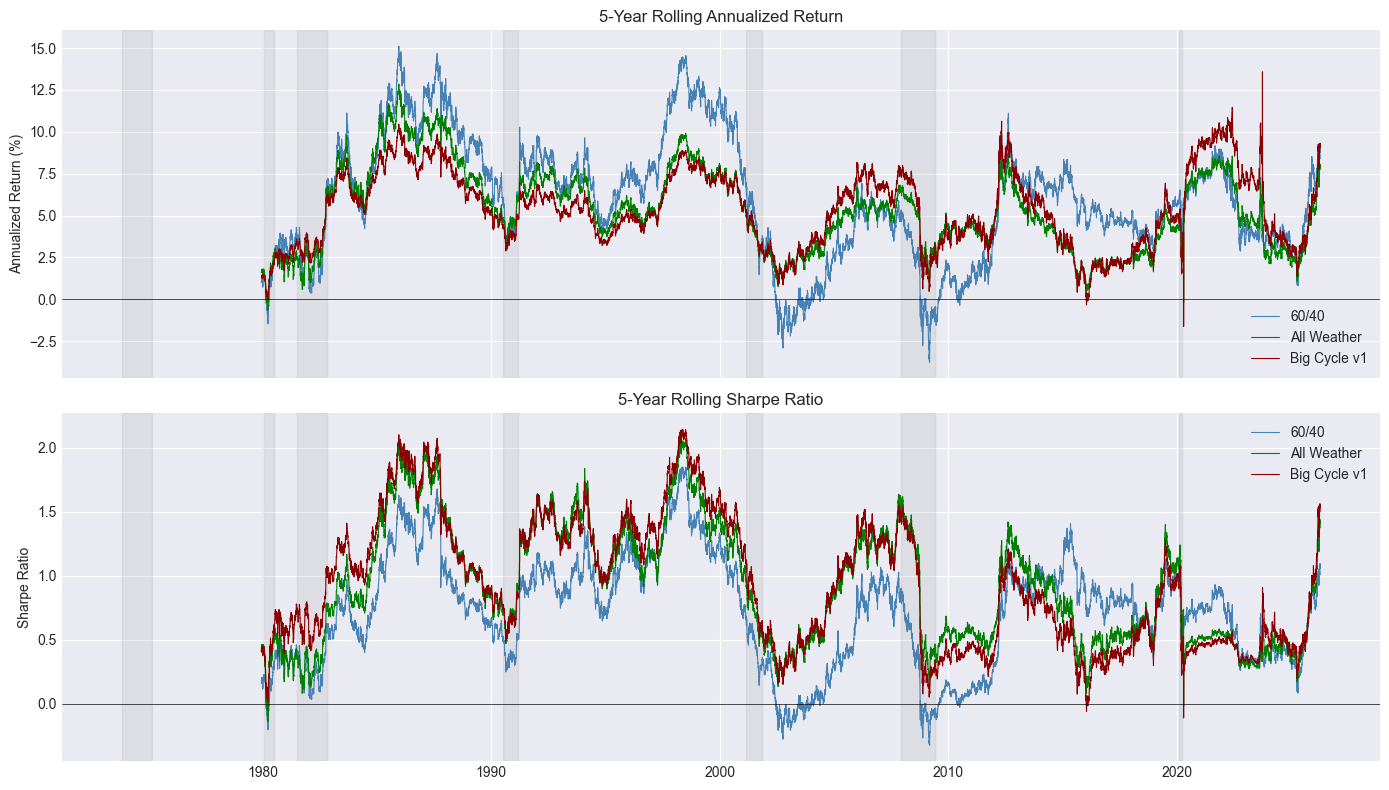

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

window = 252 * 5  # 5-year rolling

for name, result in results.items():
    rolling_ret = result.portfolio_returns.rolling(window).mean() * 252  # annualized
    rolling_vol = result.portfolio_returns.rolling(window).std() * np.sqrt(252)
    rolling_sharpe = rolling_ret / rolling_vol

    ax1.plot(rolling_ret.index, rolling_ret * 100, label=name, color=colors[name], linewidth=0.8)
    ax2.plot(rolling_sharpe.index, rolling_sharpe, label=name, color=colors[name], linewidth=0.8)

add_recessions(ax1)
ax1.set_ylabel('Annualized Return (%)')
ax1.set_title('5-Year Rolling Annualized Return')
ax1.legend()
ax1.axhline(0, color='black', linewidth=0.5)

add_recessions(ax2)
ax2.set_ylabel('Sharpe Ratio')
ax2.set_title('5-Year Rolling Sharpe Ratio')
ax2.legend()
ax2.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()